In [1]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=1
import matplotlib.pyplot as plt
import sys

from utils.io_utils import load_multiple_res
from utils.utils import get_path
from utils.pd_utils import get_persistent_feature_id, get_persistent_cycle, compute_outlier_scores
from utils.toydata_utils import get_toy_data
from utils.fig_utils import full_dist_to_color, all_full_dists, dist_to_color, full_dist_to_print, plot_edges_on_scatter


from vis_utils.plot import plot_scatter
from vis_utils.utils import load_dict
from persim import plot_diagrams
import os
import numpy as np
from sklearn.decomposition import PCA
import pickle

env: CUDA_VISIBLE_DEVICES=1
[KeOps] Warning : cuda was detected, but driver API could not be initialized. Switching to cpu only.


In [4]:
style_file = "utils.style"
plt.style.use(style_file)

In [5]:
root_path = get_path("data")
fig_path = get_path("figures")

In [7]:
distances = {
    "euclidean": [{}],
    "diffusion": [
        {"k": 15, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 15, "t": 64, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 64, "kernel": "sknn", "include_self": False},
    ],
    "eff_res": [
        {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
        {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
    ],
}

embd_dim = 50
# sigma = 0.25 # this is for drawing a verticle line, not useful here i guess......
sigmas = np.linspace(0.20, 0.60, 81)
sigmas = np.array([np.format_float_positional(sigma, precision=4, unique=True, trim='0') for sigma in sigmas]).astype(float)
seeds = [0,1,2,3,4]
# seeds = [0]
n = 5000
seed = 0

In [8]:
# load runs for toy sphere with euclidean and eff res setting
all_res_before = load_multiple_res(datasets="toy_circle_before", distances=distances, root_path=root_path, n=n, embd_dims=embd_dim, sigmas=sigmas, seeds=seeds, n_threads=10)
all_res_after = load_multiple_res(datasets="toy_circle_after", distances=distances, root_path=root_path, n=n, embd_dims=embd_dim, sigmas=sigmas, seeds=seeds, n_threads=10)


# compute outlier scores
outlier_scores_before = compute_outlier_scores(dgms=all_res_before, n_features=1, dim=1)
outlier_scores_after = compute_outlier_scores(dgms=all_res_after, n_features=1, dim=1)



Done with toy_circle_before 50 euclidean n_outliers=0, perturbation=None
Done with toy_circle_before 50 diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with toy_circle_before 50 diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with toy_circle_before 50 diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with toy_circle_before 50 diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with toy_circle_before 50 eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with toy_circle_before 50 eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None
Done with toy_circle_after 50 euclidean n_outliers=0, perturbation=None
Done with toy_circle_after 50 diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with toy_circle_after 50 diffusion_k_

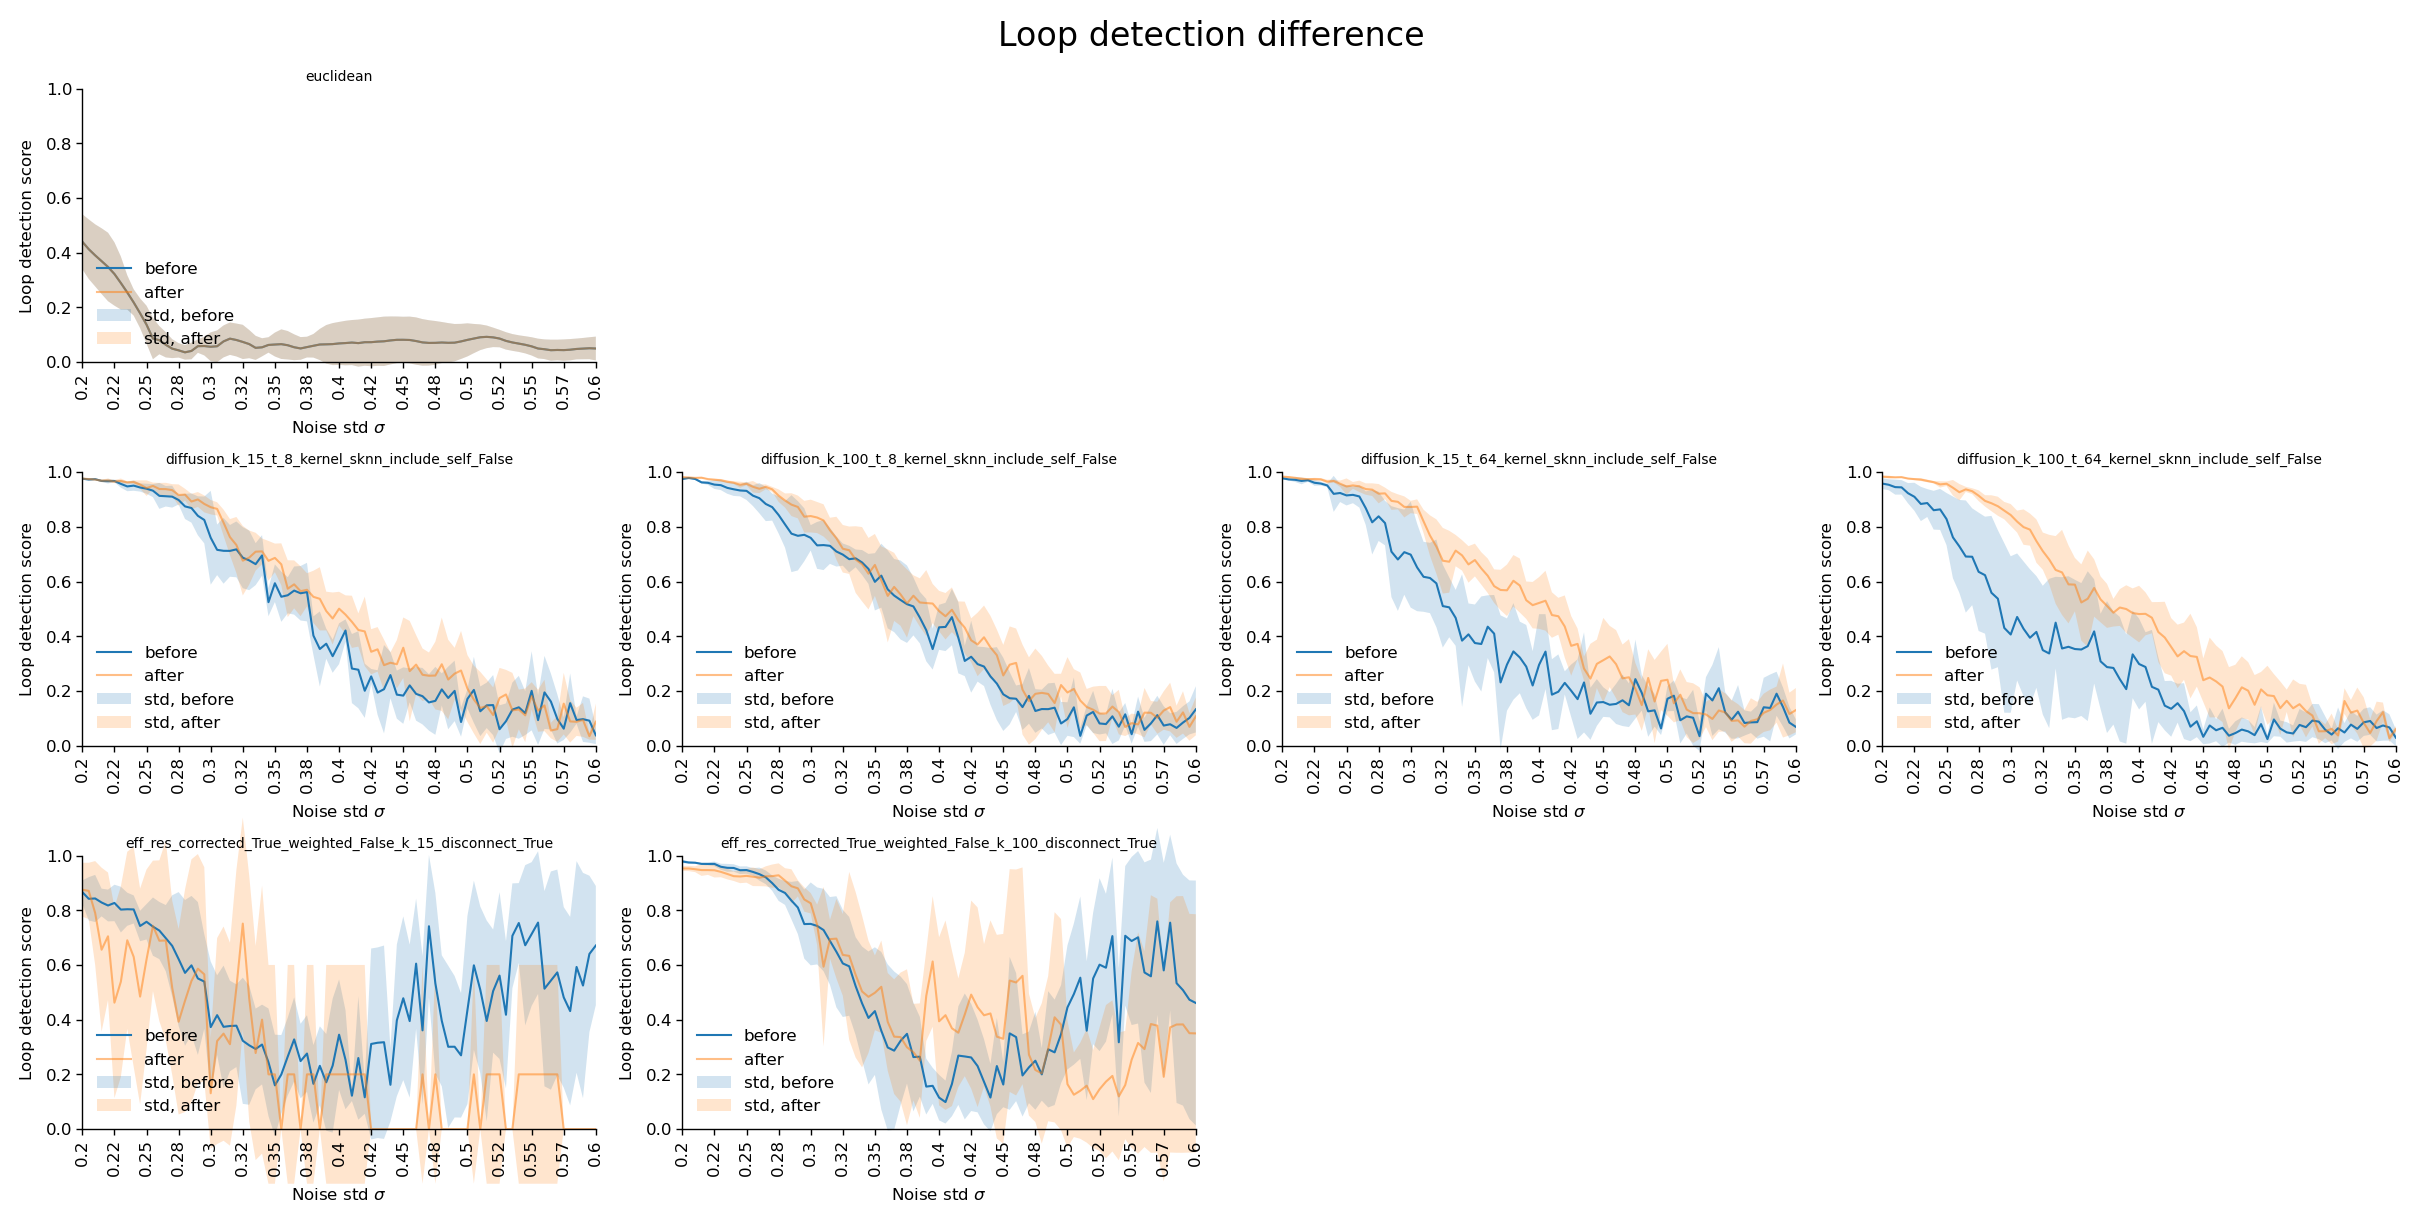

In [15]:
fig, ax = plt.subplots(3, 4, figsize=(12,6))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]


for i, distance in enumerate(outlier_scores_before.keys()):
    n_plots = len(outlier_scores_before[distance].keys())
    if n_plots<4:
        for j in range(n_plots, 4):
            ax[i][j].axis("off")
    for j, parameter in enumerate(outlier_scores_before[distance].keys()):
        outlier_score_before = outlier_scores_before[distance][parameter]
        outlier_score_after = outlier_scores_after[distance][parameter]
        ax[i][j].plot(sigmas, outlier_score_before.mean(1), label ="before",) #label=f"{parameter}",
        ax[i][j].plot(sigmas, outlier_score_after.mean(1), label ="after", alpha=0.5) 
        ax[i][j].fill_between(sigmas, 
                            outlier_score_before.mean(1)+outlier_score_before.std(1), 
                            outlier_score_before.mean(1)-outlier_score_before.std(1), 
                            # color=full_dist_to_color[distance],
                            label ="std, before",
                            alpha=0.2,
                            edgecolor=None,
                            clip_on=False)
        ax[i][j].fill_between(sigmas, 
                            outlier_score_after.mean(1)+outlier_score_after.std(1), 
                            outlier_score_after.mean(1)-outlier_score_after.std(1), 
                            label ="std, after",
                            # color=colors[j],
                            alpha=0.2,
                            edgecolor=None,
                            clip_on=False)

        ax[i][j].set_ylim(0.0, 1.0)
        # ax[i][j].set_xlim(0.2, 0.35)
        # ax[i][j].legend([f"{b}, {a}" for a in outlier_scores_before[distance].keys() for b in ["before", "after", "std"]], loc="lower left", frameon=False)
        ax[i][j].legend(loc="lower left", frameon=False)

        ax[i][j].set_ylabel("Loop detection score")
        ax[i][j].set_xlabel(r"Noise std $\sigma$")
        ax[i][j].set_title(f"{parameter}",  fontsize = 5)
        ax[i][j].set_xticks(np.linspace(0.2, 0.6, 17))
        ax[i][j].set_xticklabels(np.round(np.linspace(0.2, 0.6, 17),2 ), rotation = 90)

    
    
fig.suptitle("Loop detection difference", fontsize = 12) 
fig.savefig(os.path.join(get_path("figures"), f"toy_circle_loop_detection_variance.png"), dpi=300)

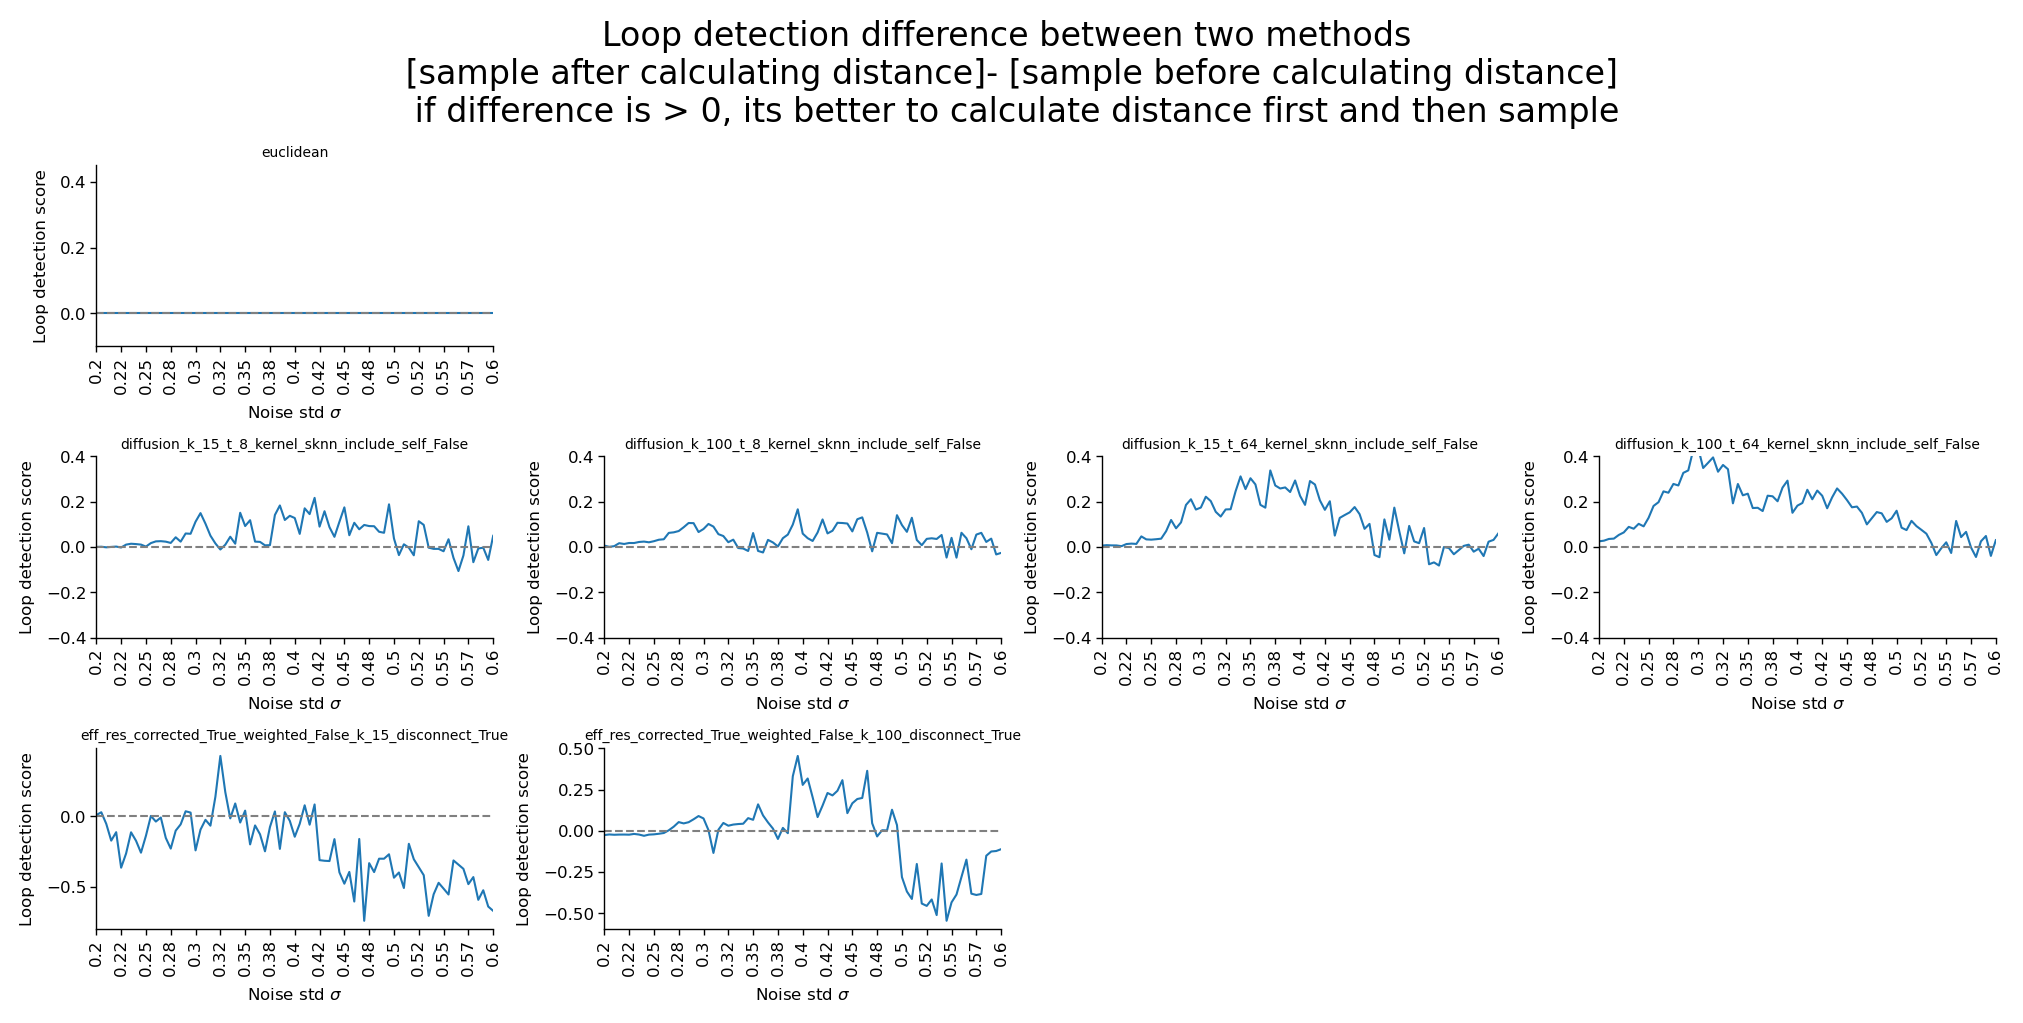

In [ ]:
fig, ax = plt.subplots(3, 4, figsize=(10,5))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]


for i, distance in enumerate(list(outlier_scores_before.keys())):
    n_plots = len(outlier_scores_before[distance].keys())
    if n_plots<4:
        for j in range(n_plots, 4):
            ax[i][j].axis("off")
    for j, parameter in enumerate(outlier_scores_before[distance].keys()):
        outlier_score_before = outlier_scores_before[distance][parameter]
        outlier_score_after = outlier_scores_after[distance][parameter]
        ax[i][j].plot(sigmas, outlier_score_after.mean(1)- outlier_score_before.mean(1)) #, color = colors[j] ,label ="after-before"
        
        if i ==0:
            ax[i][j].set_ylim(-0.1, 0.45)
        elif i ==1:
            ax[i][j].set_ylim(-0.4, 0.4)
        
        ax[i][j].hlines(y=0, xmin=0.2, xmax=0.6, color='grey', linestyle='--')
        ax[i][j].set_xlim(0.2, 0.35)
        # ax[i][j].legend([f"{b}, {a}" for a in outlier_scores_before[distance].keys() for b in ["before", "after", "std"]], loc="lower left", frameon=False)
        # ax[i][j].legend(loc="lower left", frameon=False)

        ax[i][j].set_ylabel("Loop detection score")
        ax[i][j].set_xlabel(r"Noise std $\sigma$")
        ax[i][j].set_title(f"{parameter}",  fontsize = 5)
        ax[i][j].set_xticks(np.linspace(0.2, 0.6, 17))
        ax[i][j].set_xticklabels(np.round(np.linspace(0.2, 0.6, 17),2 ), rotation = 90)
    
    
fig.suptitle("Loop detection difference between two methods \n [sample after calculating distance]- [sample before calculating distance] \n if difference is > 0, its better to calculate distance first and then sample", fontsize = 12) 
fig.savefig(os.path.join(get_path("figures"), f"toy_circle_loop_detection_difference.png"), dpi=300)

## test eff_res

In [ ]:
outlier_score_before.shape

(81, 5)

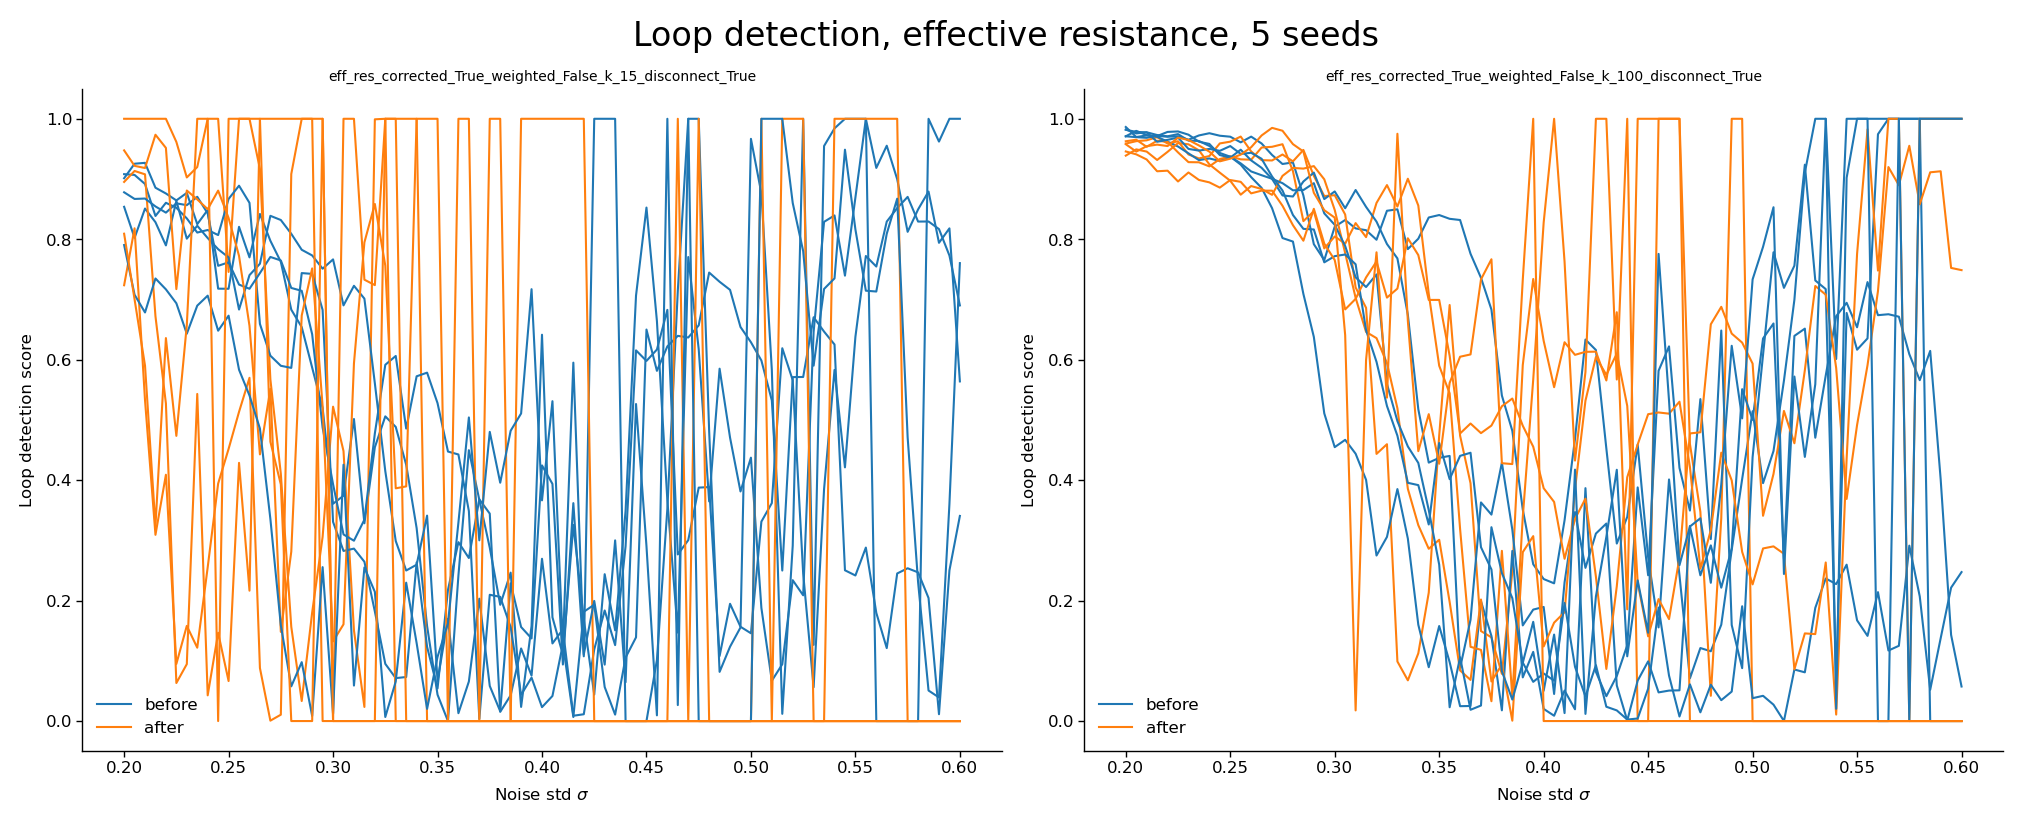

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

distance = list(outlier_scores_before.keys())[2] # only eff_res
for j, parameter in enumerate(outlier_scores_before[distance].keys()):
    
    outlier_score_before = outlier_scores_before[distance][parameter]
    outlier_score_after = outlier_scores_after[distance][parameter]
    
    ax[j].plot(sigmas, outlier_score_before[:,0], label =f"before", color = '#1f77b4') #label=f"{parameter}",
    ax[j].plot(sigmas, outlier_score_after[:,0], label =f"after", color = "#ff7f0e") 
    for i in range(1, outlier_score_before.shape[1]):
        ax[j].plot(sigmas, outlier_score_before[:,i],  color = '#1f77b4') #label=f"{parameter}",
        ax[j].plot(sigmas, outlier_score_after[:,i],  color = "#ff7f0e") 

    # ax[j].set_ylim(0.0, 1.0)
    # ax[j].set_xlim(0.2, 0.35)
    # ax[j].legend([f"{b}, {a}" for a in outlier_scores_before[distance].keys() for b in ["before", "after", "std"]], loc="lower left", frameon=False)
    ax[j].legend(loc="lower left", frameon=False)

    ax[j].set_ylabel("Loop detection score")
    ax[j].set_xlabel(r"Noise std $\sigma$")
    ax[j].set_title(f"{parameter}",  fontsize = 5)
    # ax[j].set_xticks(np.linspace(0.2, 0.6, 17))
    # ax[j].set_xticklabels(np.round(np.linspace(0.2, 0.6, 17),2 ), rotation = 90)

    
    
fig.suptitle("Loop detection, effective resistance, 5 seeds ", fontsize = 12) 
fig.savefig(os.path.join(get_path("figures"), f"toy_circle_loop_detection_eff_res.png"), dpi=300)